In [ ]:
# ============================================================
# SETUP: Mount Google Drive, define paths, install packages
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
DATA_PATH  = "/content/drive/MyDrive/MSc_Dissertation/data/"    # where the csv lives
MODEL_PATH = "/content/drive/MyDrive/MSc_Dissertation/models/"  # where outputs are saved
os.makedirs(MODEL_PATH, exist_ok=True)                          # create models folder if missing

!pip install xgboost imbalanced-learn shap lime -q

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# ============================================================
# IMPORTS: data handling, models, SMOTE pipeline, metrics
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, time, glob, warnings
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline   # pipeline that runs SMOTE INSIDE each CV fold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.calibration import calibration_curve
warnings.filterwarnings('ignore')
np.random.seed(42)   # reproducibility — fixed seed everywhere

In [ ]:
# ============================================================
# STEP 1: LOAD AND PREPROCESS
#   - robustly find the csv, drop ID/meta cols, impute NaNs,
#     70/30 stratified split, min-max scale
#   - SMOTE here is ONLY for SHAP background/saving (not CV)
# ============================================================
print("="*60); print("STEP 1: LOADING AND PREPROCESSING"); print("="*60)

# Robust load: match the cell2cell csv regardless of spaces/underscores in its name
csv_matches = [f for f in glob.glob(DATA_PATH + "*.csv") if "cell2cell" in f.lower()]
assert csv_matches, f"No cell2cell CSV found in {DATA_PATH}"
csv_path = csv_matches[0]
print(f"Loading: {csv_path}")
df = pd.read_csv(csv_path)
print(f"Raw dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Drop ID / metadata columns that aren't predictive
drop_cols = ['Unnamed: 0', 'X', 'customer', 'traintest', 'churndep']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
print(f"After cleanup: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Separate features (X) and target (y), then median-impute missing values
X = df.drop('churn', axis=1)
y = df['churn']
X = X.fillna(X.median())
print(f"Missing values imputed. Remaining NaN: {X.isnull().sum().sum()}")

# 70/30 stratified split (keeps churn ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
print(f"\nTrain: {X_train.shape[0]:,} ({y_train.mean()*100:.1f}% churn)")
print(f"Test:  {X_test.shape[0]:,} ({y_test.mean()*100:.1f}% churn)")

# Min-max scaling (fit on train only, then apply to test)
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
                              columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),
                              columns=X_test.columns, index=X_test.index)
print("Min-Max scaling applied.")

# Standalone SMOTE — ONLY for SHAP background + saving (NOT used in CV, so no leakage)
X_train_resampled, y_train_resampled = SMOTE(random_state=42).fit_resample(
    X_train_scaled, y_train)
feature_names = X.columns.tolist()
print(f"Background resample: {X_train_resampled.shape[0]:,} rows (balanced)")

STEP 1: LOADING AND PREPROCESSING
Loading: /content/drive/MyDrive/MSc_Dissertation/data/cell2cell-duke univeristy.csv
Raw dataset: 71,047 rows × 72 columns
After cleanup: 71,047 rows × 67 columns
Missing values imputed. Remaining NaN: 0

Train: 49,732 (29.0% churn)
Test:  21,315 (29.0% churn)
Min-Max scaling applied.
Background resample: 70,612 rows (balanced)


In [ ]:
# ============================================================
# STEP 2: TUNE LOGISTIC REGRESSION  (interpretable baseline)
#   SMOTE runs inside each CV fold via the pipeline -> honest CV score
# ============================================================
print("\n"+"="*60); print("STEP 2: TUNING LOGISTIC REGRESSION"); print("="*60)

lr_pipe = ImbPipeline([('smote', SMOTE(random_state=42)),
                       ('clf', LogisticRegression(random_state=42, max_iter=1000))])
lr_param_grid = {'clf__C': [0.01, 0.1, 1, 10], 'clf__penalty': ['l2'], 'clf__solver': ['lbfgs']}

lr_grid = GridSearchCV(lr_pipe, lr_param_grid,
                       cv=StratifiedKFold(5, shuffle=True, random_state=42),
                       scoring='roc_auc', n_jobs=-1, verbose=1)
start = time.time(); lr_grid.fit(X_train_scaled, y_train); lr_time = time.time()-start  # fit on ORIGINAL imbalanced train
lr_best = lr_grid.best_estimator_.named_steps['clf']   # extract bare classifier for Day 2 SHAP
print(f"Best params: {lr_grid.best_params_}")
print(f"Honest CV AUC-ROC: {lr_grid.best_score_:.4f}  |  Time: {lr_time:.1f}s")


STEP 2: TUNING LOGISTIC REGRESSION
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Honest CV AUC-ROC: 0.6104  |  Time: 80.5s


In [ ]:
# ============================================================
# STEP 3: TUNE RANDOM FOREST  (accuracy-interpretability mid-point)
#   Trimmed grid (4 candidates) keeps runtime to a few minutes
# ============================================================
print("\n"+"="*60); print("STEP 3: TUNING RANDOM FOREST"); print("="*60)

rf_pipe = ImbPipeline([('smote', SMOTE(random_state=42)),
                       ('clf', RandomForestClassifier(random_state=42, n_jobs=1))])
rf_param_grid = {
    'clf__n_estimators':      [200],
    'clf__max_depth':         [10, 20],
    'clf__min_samples_leaf':  [2],
    'clf__min_samples_split': [5, 10],
}  # 4 candidates × 5 folds = 20 fits

rf_grid = GridSearchCV(rf_pipe, rf_param_grid,
                       cv=StratifiedKFold(5, shuffle=True, random_state=42),
                       scoring='roc_auc', n_jobs=-1, verbose=1)
start = time.time(); rf_grid.fit(X_train_scaled, y_train); rf_time = time.time()-start
rf_best = rf_grid.best_estimator_.named_steps['clf']
print(f"Best params: {rf_grid.best_params_}")
print(f"Honest CV AUC-ROC: {rf_grid.best_score_:.4f}  |  Time: {rf_time:.1f}s")


STEP 3: TUNING RANDOM FOREST
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'clf__max_depth': 20, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
Honest CV AUC-ROC: 0.6536  |  Time: 809.0s


In [ ]:
# ============================================================
# STEP 4: TUNE XGBOOST  (high-performance, opaque — main explanation target)
#   Note: no 'use_label_encoder' (removed in XGBoost 2.x)
# ============================================================
print("\n"+"="*60); print("STEP 4: TUNING XGBOOST"); print("="*60)

xgb_pipe = ImbPipeline([('smote', SMOTE(random_state=42)),
                        ('clf', XGBClassifier(random_state=42,
                                              eval_metric='logloss', n_jobs=1))])
xgb_param_grid = {
    'clf__n_estimators':     [200, 300],
    'clf__max_depth':        [5, 7],
    'clf__learning_rate':    [0.05, 0.1],
    'clf__subsample':        [0.8],
    'clf__colsample_bytree': [1.0],
}  # 8 candidates × 5 folds = 40 fits

xgb_grid = GridSearchCV(xgb_pipe, xgb_param_grid,
                        cv=StratifiedKFold(5, shuffle=True, random_state=42),
                        scoring='roc_auc', n_jobs=-1, verbose=1)
start = time.time(); xgb_grid.fit(X_train_scaled, y_train); xgb_time = time.time()-start
xgb_best = xgb_grid.best_estimator_.named_steps['clf']
print(f"Best params: {xgb_grid.best_params_}")
print(f"Honest CV AUC-ROC: {xgb_grid.best_score_:.4f}  |  Time: {xgb_time:.1f}s")


STEP 4: TUNING XGBOOST
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 300, 'clf__subsample': 0.8}
Honest CV AUC-ROC: 0.6739  |  Time: 392.6s


In [ ]:
# ============================================================
# STEP 5: FINAL EVALUATION ON HELD-OUT TEST SET
#   Reports accuracy, precision, recall, F1, AUC for all 3 models
# ============================================================
print("\n"+"="*60); print("STEP 5: FINAL EVALUATION ON TEST SET"); print("="*60)

models = {'Logistic Regression': lr_best, 'Random Forest': rf_best, 'XGBoost': xgb_best}
results, predictions = {}, {}
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'AUC-ROC':   roc_auc_score(y_test, y_prob),
    }
    predictions[name] = {'y_pred': y_pred, 'y_prob': y_prob}
    print(f"\n--- {name} ---")
    for m, v in results[name].items(): print(f"  {m}: {v:.4f}")

results_df = pd.DataFrame(results).T
print("\n"+"="*60); print("MODEL COMPARISON TABLE"); print("="*60)
print("\n"+results_df.round(4).to_string())
best_model_name = results_df['AUC-ROC'].idxmax()   # pick best by AUC for the SHAP/LIME stage
print(f"\n>>> Best model: {best_model_name} (AUC-ROC: {results_df.loc[best_model_name,'AUC-ROC']:.4f}) <<<")


STEP 5: FINAL EVALUATION ON TEST SET

--- Logistic Regression ---
  Accuracy: 0.5724
  Precision: 0.3602
  Recall: 0.6105
  F1-Score: 0.4531
  AUC-ROC: 0.6150

--- Random Forest ---
  Accuracy: 0.6999
  Precision: 0.4641
  Recall: 0.2229
  F1-Score: 0.3011
  AUC-ROC: 0.6587

--- XGBoost ---
  Accuracy: 0.7225
  Precision: 0.5655
  Recall: 0.1879
  F1-Score: 0.2821
  AUC-ROC: 0.6799

MODEL COMPARISON TABLE

                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.5724     0.3602  0.6105    0.4531   0.6150
Random Forest          0.6999     0.4641  0.2229    0.3011   0.6587
XGBoost                0.7225     0.5655  0.1879    0.2821   0.6799

>>> Best model: XGBoost (AUC-ROC: 0.6799) <<<


In [ ]:
# ============================================================
# STEP 6: DETAILED CLASSIFICATION REPORTS (per-class precision/recall)
# ============================================================
print("\n"+"="*60); print("STEP 6: CLASSIFICATION REPORTS"); print("="*60)
for name in models:
    print(f"\n--- {name} ---")
    print(classification_report(y_test, predictions[name]['y_pred'],
                                target_names=['Non-Churn', 'Churn']))


STEP 6: CLASSIFICATION REPORTS

--- Logistic Regression ---
              precision    recall  f1-score   support

   Non-Churn       0.78      0.56      0.65     15132
       Churn       0.36      0.61      0.45      6183

    accuracy                           0.57     21315
   macro avg       0.57      0.58      0.55     21315
weighted avg       0.66      0.57      0.59     21315


--- Random Forest ---
              precision    recall  f1-score   support

   Non-Churn       0.74      0.89      0.81     15132
       Churn       0.46      0.22      0.30      6183

    accuracy                           0.70     21315
   macro avg       0.60      0.56      0.56     21315
weighted avg       0.66      0.70      0.66     21315


--- XGBoost ---
              precision    recall  f1-score   support

   Non-Churn       0.74      0.94      0.83     15132
       Churn       0.57      0.19      0.28      6183

    accuracy                           0.72     21315
   macro avg       0.65    


STEP 7: VISUALISATIONS


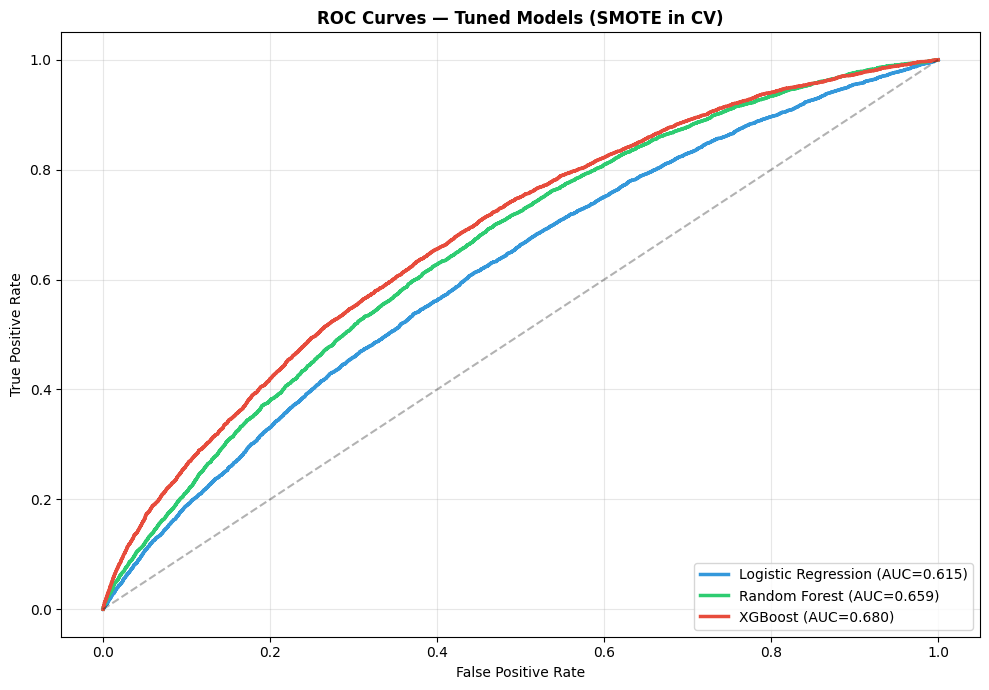

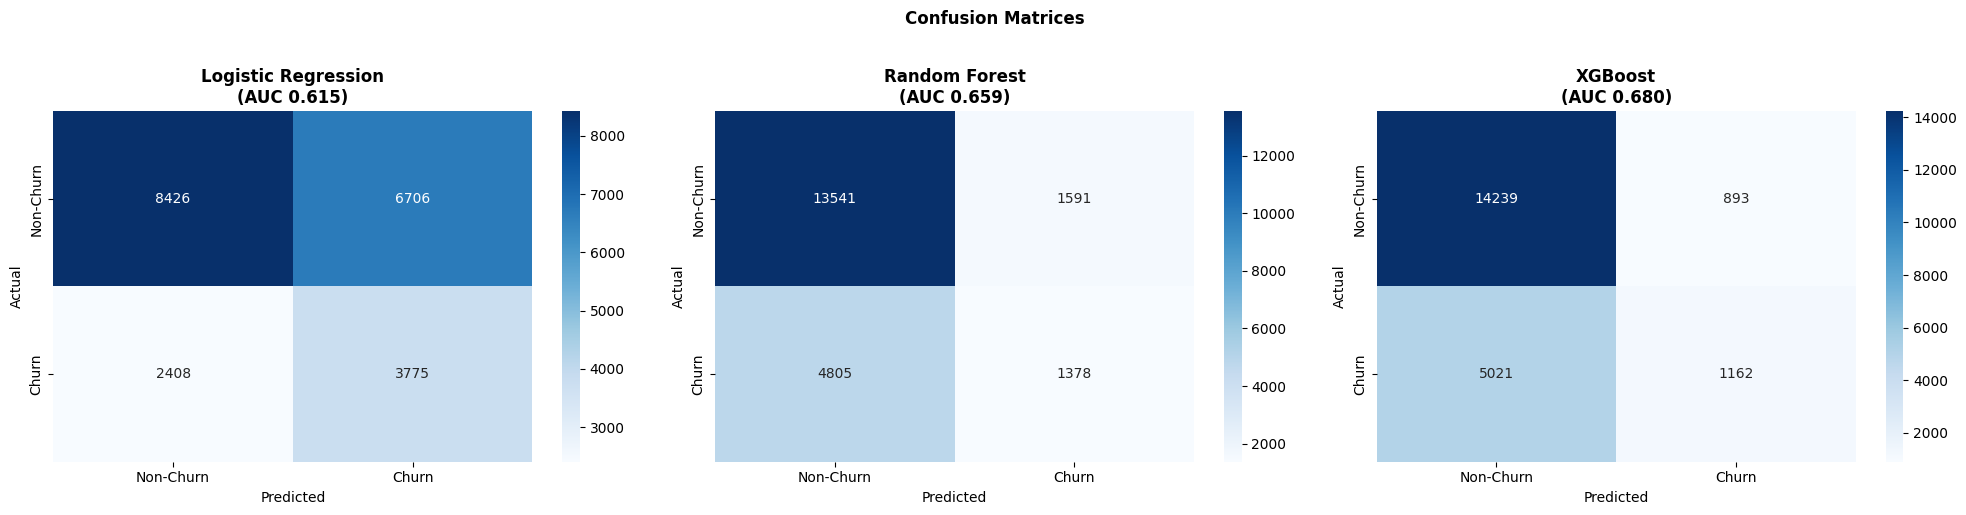

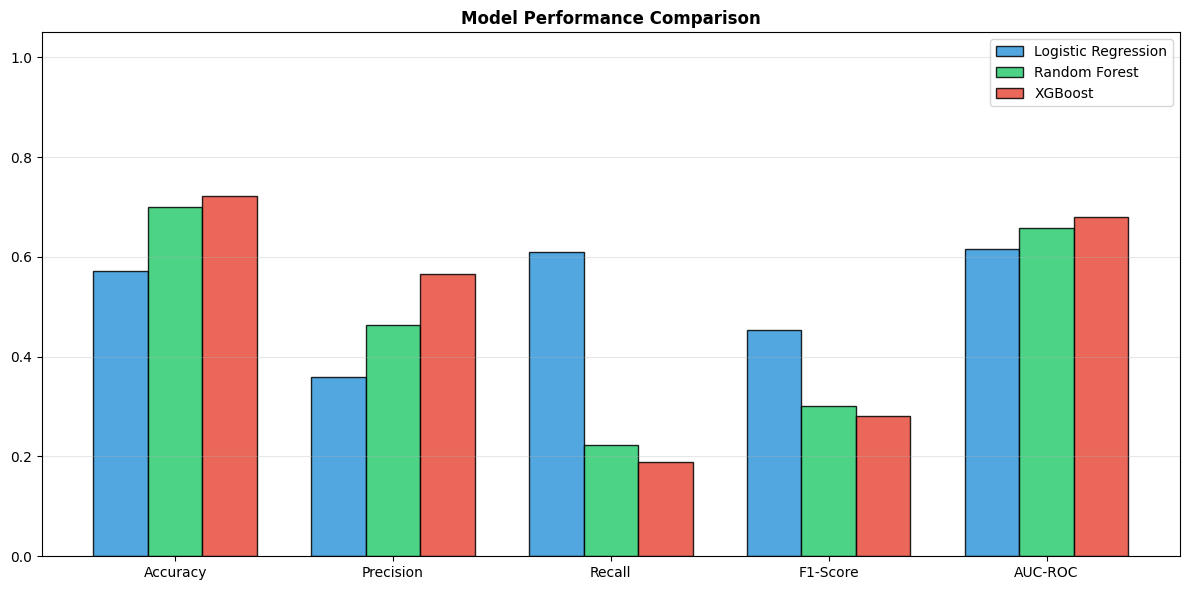

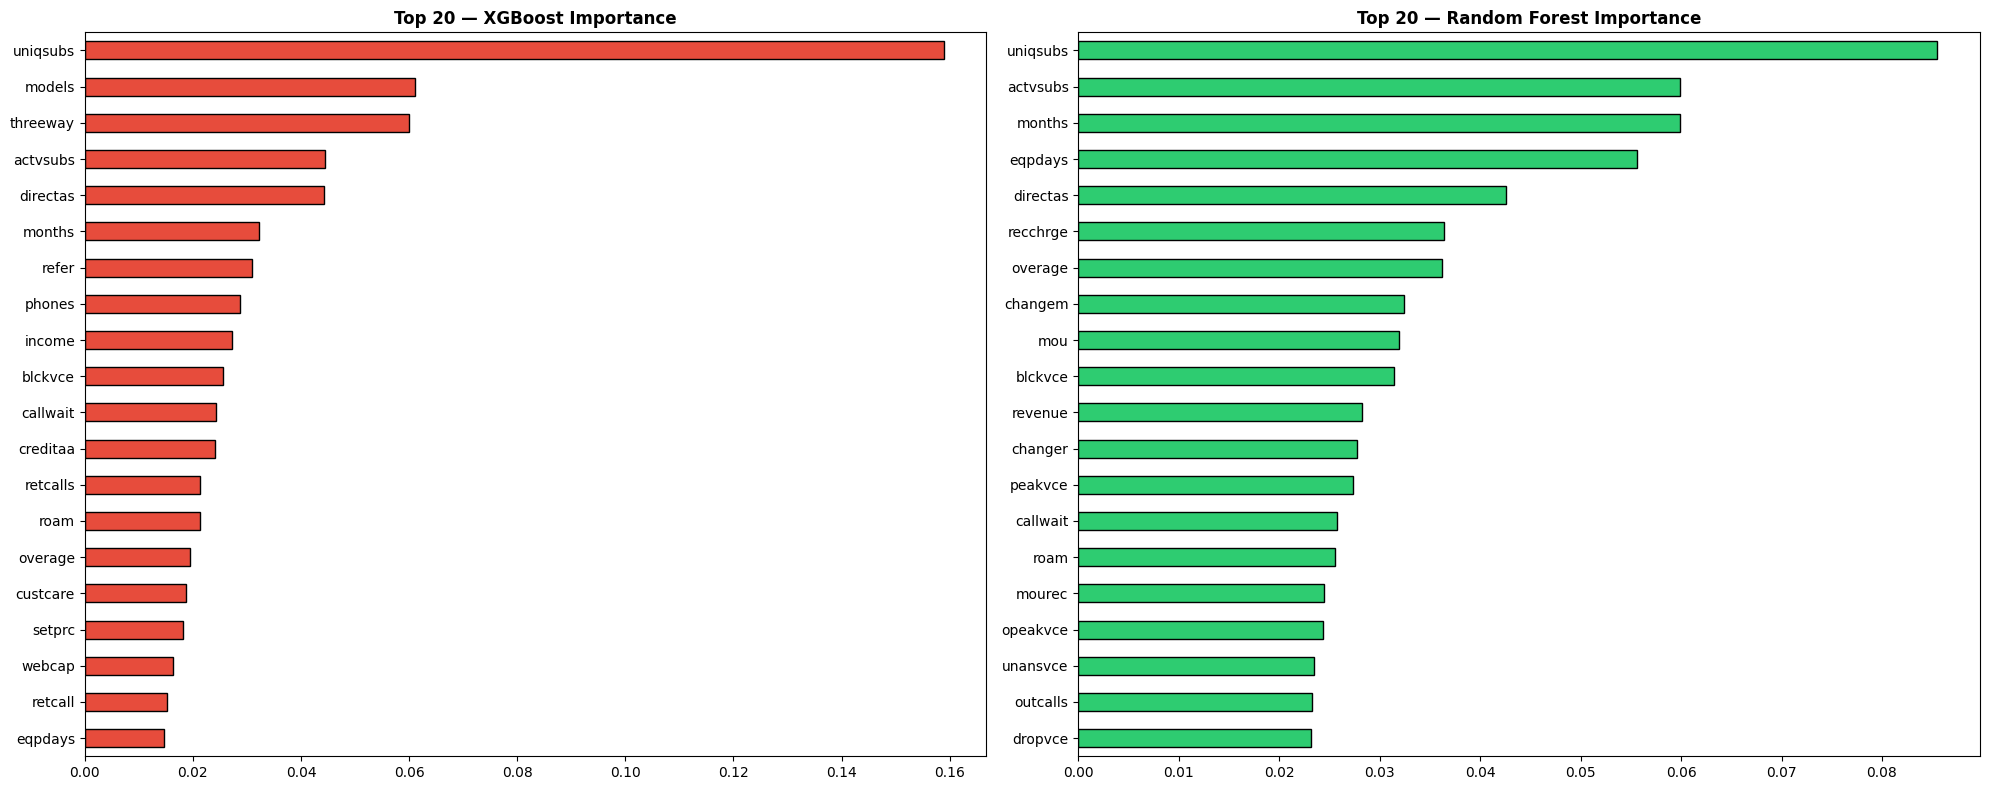

In [ ]:
# ============================================================
# STEP 7: VISUALISATIONS
#   ROC curves, confusion matrices, comparison bar, feature importances
# ============================================================
print("\n"+"="*60); print("STEP 7: VISUALISATIONS"); print("="*60)
colors = {'Logistic Regression':'#3498db','Random Forest':'#2ecc71','XGBoost':'#e74c3c'}

# --- ROC curves (higher = better ranking of churners) ---
plt.figure(figsize=(10, 7))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, predictions[name]['y_prob'])
    plt.plot(fpr, tpr, color=colors[name], lw=2.5,
             label=f"{name} (AUC={results[name]['AUC-ROC']:.3f})")
plt.plot([0,1],[0,1],'k--',alpha=.3)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Tuned Models (SMOTE in CV)', fontweight='bold')
plt.legend(loc='lower right'); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

# --- Confusion matrices (raw counts per class) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Churn','Churn'], yticklabels=['Non-Churn','Churn'])
    ax.set_title(f"{name}\n(AUC {results[name]['AUC-ROC']:.3f})", fontweight='bold')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices', fontweight='bold', y=1.02); plt.tight_layout(); plt.show()

# --- Metric comparison bar chart ---
fig, ax = plt.subplots(figsize=(12, 6))
xpos = np.arange(len(results_df.columns)); width = 0.25
for i, (mdl, col) in enumerate(zip(results_df.index, colors.values())):
    ax.bar(xpos + i*width, results_df.loc[mdl].values, width, label=mdl,
           color=col, edgecolor='black', alpha=.85)
ax.set_xticks(xpos + width); ax.set_xticklabels(results_df.columns)
ax.set_title('Model Performance Comparison', fontweight='bold')
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(axis='y', alpha=.3); plt.tight_layout(); plt.show()

# --- Built-in feature importances (XGBoost + Random Forest) ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
pd.Series(xgb_best.feature_importances_, index=feature_names).sort_values().tail(20).plot(
    kind='barh', ax=axes[0], color='#e74c3c', edgecolor='black')
axes[0].set_title('Top 20 — XGBoost Importance', fontweight='bold')
pd.Series(rf_best.feature_importances_, index=feature_names).sort_values().tail(20).plot(
    kind='barh', ax=axes[1], color='#2ecc71', edgecolor='black')
axes[1].set_title('Top 20 — Random Forest Importance', fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# STEP 8: SAVE MODELS AND DATA  (Day 2 loads these exact files)
# ============================================================
print("\n"+"="*60); print("STEP 8: SAVING MODELS AND DATA"); print("="*60)
for name, model in models.items():
    fn = name.lower().replace(' ', '_') + '_tuned.pkl'   # e.g. xgboost_tuned.pkl
    pickle.dump(model, open(MODEL_PATH + fn, 'wb')); print(f"Saved: {fn}")
pickle.dump(scaler, open(MODEL_PATH + 'scaler.pkl', 'wb')); print("Saved: scaler.pkl")

# test_data.pkl bundles everything Day 2/3 need (test set + SHAP background + feature names)
test_data = {'X_test_scaled': X_test_scaled, 'y_test': y_test,
             'X_train_resampled': X_train_resampled, 'y_train_resampled': y_train_resampled,
             'feature_names': feature_names}
pickle.dump(test_data, open(MODEL_PATH + 'test_data.pkl', 'wb')); print("Saved: test_data.pkl")
results_df.to_csv(MODEL_PATH + 'model_comparison_results.csv'); print("Saved: model_comparison_results.csv")


STEP 8: SAVING MODELS AND DATA
Saved: logistic_regression_tuned.pkl
Saved: random_forest_tuned.pkl
Saved: xgboost_tuned.pkl
Saved: scaler.pkl
Saved: test_data.pkl
Saved: model_comparison_results.csv


In [ ]:
# ============================================================
# STEP 9: SUMMARY  (honest CV vs test — should now be close)
# ============================================================
print("\n"+"="*60); print("DAY 1 SUMMARY"); print("="*60)
print(f"""
Best Model: {best_model_name}  (AUC-ROC {results_df.loc[best_model_name,'AUC-ROC']:.4f})

Honest CV AUC (SMOTE inside CV — no leakage):
  LR:  {lr_grid.best_score_:.4f}
  RF:  {rf_grid.best_score_:.4f}
  XGB: {xgb_grid.best_score_:.4f}

Test-set results:
{results_df.round(4).to_string()}

Saved: 3 models, scaler, test_data.pkl, model_comparison_results.csv
NEXT: Day 2 — SHAP
""")
print("DAY 1 COMPLETE.")


DAY 1 SUMMARY

Best Model: XGBoost  (AUC-ROC 0.6799)

Honest CV AUC (SMOTE inside CV — no leakage):
  LR:  0.6104
  RF:  0.6536
  XGB: 0.6739

Test-set results:
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.5724     0.3602  0.6105    0.4531   0.6150
Random Forest          0.6999     0.4641  0.2229    0.3011   0.6587
XGBoost                0.7225     0.5655  0.1879    0.2821   0.6799

Saved: 3 models, scaler, test_data.pkl, model_comparison_results.csv
NEXT: Day 2 — SHAP

DAY 1 COMPLETE.
